# Access 4DMED-SEA MIOST Lagrangian Eddies
    * Original Data Source: https://zenodo.org/records/11384073
    * Reference: https://doi.org/10.1016/j.ocemod.2010.12.006
    * OSC entry: https://opensciencedata.esa.int/stac-browser/#/products/4dmed-2d-alt-miost-le-24/collection.json
    * License: CC-BY-4.0

In [1]:
import xarray as xr
import numpy as np
import pandas as pd


zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/fsle.zarr/'

In [2]:
ds = xr.open_dataset(zarr_href)
ds

<xarray.Dataset> Size: 7GB
Dimensions:  (time: 2300, y: 376, x: 1010)
Coordinates:
  * time     (time) datetime64[ns] 18kB 2016-04-01 2016-04-02 ... 2022-07-23
    lat      (y, x) float32 2MB ...
    lon      (y, x) float32 2MB ...
Dimensions without coordinates: y, x
Data variables:
    fsle     (time, y, x) float64 7GB ...
Attributes:
    title:         Altimetry derived finite-size Lyapunov exponents
    long_title:    Finite-size Lyapunov Exponents in the Mediterranean Sea de...
    institution:   IMEDEA (UIB-CSIC)
    source:        Algorithm developed by I. Hernandez-Carrasco
    source2:       Hernandez-Carrasco et al, 2011, Ocean modelling. https://d...
    CreationDate:  2024/05/29 11:45:22
    CreatedBy:     D. Cortes-Morales (dcortes@imedea.uib-csic.es)
    Funding:        4DMED-SEA Project - European Space Agency

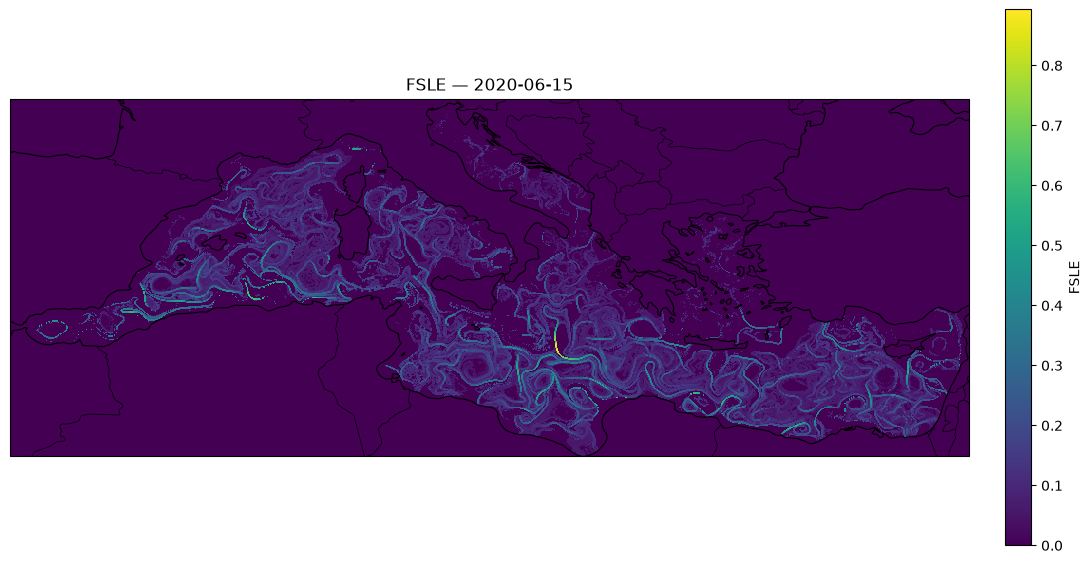

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Choose date
date = "2020-06-15"

# Select FSLE for that date
fsle_day = ds["fsle"].sel(time=date)

# 2-D coordinates
lon = ds["lon"]
lat = ds["lat"]

# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot FSLE
pcm = ax.pcolormesh(
    lon,
    lat,
    fsle_day,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)



# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("FSLE")

ax.set_title(f"FSLE - {date}")

plt.tight_layout()
plt.show()

## Find strong and persistent currents in June 2022

In [6]:
target_month = "2022-06"

fsle_month = ds.fsle.sel(time=target_month).compute()

In [15]:
strong_fsle = float(
    fsle_month.quantile(
        0.90,
        dim=("time", "y", "x"),
        skipna=True
    )
)

print(f"Monthly 90th-percentile threshold: {strong_fsle:.3f} day⁻¹")

Monthly 90th-percentile threshold: 0.100 day⁻¹


In [16]:
valid_days = fsle_month.notnull().sum("time")

persistence = (
    (fsle_month >= strong_fsle).sum("time") / valid_days
).where(valid_days > 0)

mean_fsle = fsle_month.mean("time", skipna=True)
mean_fsle

<xarray.DataArray 'fsle' (y: 376, x: 1010)> Size: 3MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(376, 1010))
Coordinates:
    lat      (y, x) float32 2MB 30.31 30.31 30.31 30.31 ... 45.94 45.94 45.94
    lon      (y, x) float32 2MB -6.021 -5.979 -5.937 ... 35.94 35.98 36.02
Dimensions without coordinates: y, x
Attributes:
    long_name:    backward Finite Size Lyapunov Exponents
    units:        1/days
    parameters1:  amplification factor: alpha = 30 (deltaf = alfa*delta0)
    parameters2:  delta0 = 1/24 degrees
    parameters3:  Fourth-Order Runge-Kutta time step: 1 hour

Text(0.5, 1.0, 'Persistence of strong backward-FSLE structures\nMediterranean Sea, June 2022')

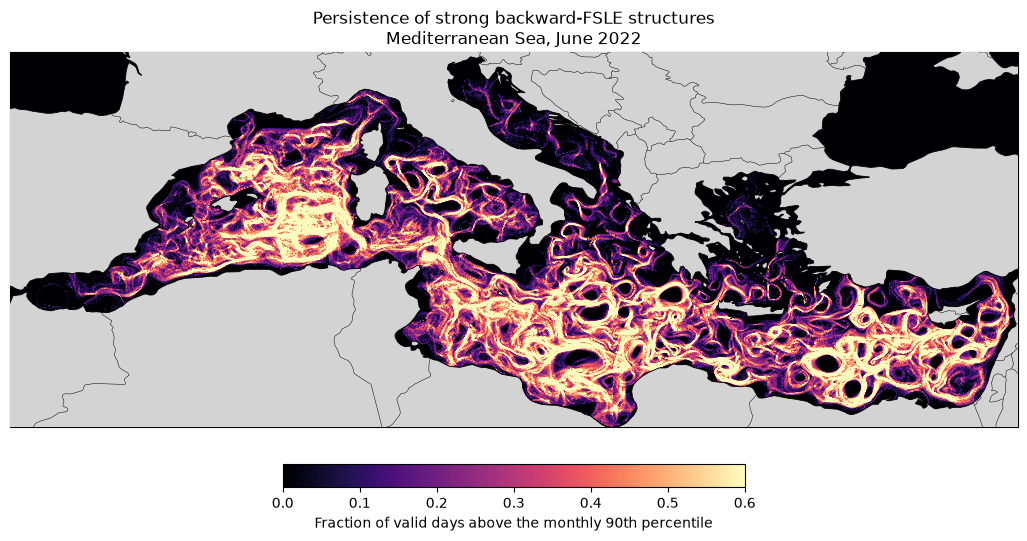

In [26]:
# visualise

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=projection)

mesh = ax.pcolormesh(
    ds.lon,
    ds.lat,
    persistence,
    transform=projection,
    shading="auto",
    cmap="magma",
    vmin=0,
    vmax=0.6
)

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, zorder=4)

colorbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05
)

colorbar.set_label("Fraction of valid days above the monthly 90th percentile")

ax.set_title(
    "Persistence of strong backward-FSLE structures\n"
    "Mediterranean Sea, June 2022"
)

In [27]:
candidate_mask = persistence >= 0.30

candidates = pd.DataFrame({
    "longitude": ds.lon.where(candidate_mask).values.ravel(),
    "latitude": ds.lat.where(candidate_mask).values.ravel(),
    "persistence": persistence.where(candidate_mask).values.ravel(),
    "mean_fsle_day-1": mean_fsle.where(candidate_mask).values.ravel()
}).dropna()

candidates = candidates.sort_values(
    ["persistence", "mean_fsle_day-1"],
    ascending=False
)

candidates

,longitude,latitude,persistence,mean_fsle_day-1
91843,33.271530,34.062347,1.0,0.493683
122671,13.187649,35.353935,1.0,0.443226
122670,13.145982,35.353935,1.0,0.440894
57164,19.146099,32.645767,1.0,0.438103
123678,13.062648,35.395599,1.0,0.435504
...,...,...,...,...
199460,14.395991,38.520409,0.3,0.036817
143145,24.604599,36.187218,0.3,0.035814
202504,14.979329,38.645401,0.3,0.035521
236518,1.395892,40.061981,0.3,0.035517
